Following topics will be covered in this notebook:

* Understanding word embeddings Demystifying Word2vec.
* Training a Word2vec model Word mover's distance.

## Brief Intro to __Word Embeddings__

Word embedding is a learned representation of a word wherein each word is represented using a vector in n-dimensional space. Words with similar meanings should have similar representations.
Word2vec captures relationships in text; consequently, similar words have similar representations.

A very frequently used example deals with the embedding of King, Man, Queen, and Woman. 
The thought process here is that the relationship of Man:King is the same as Woman:Queen. The Word2vec algorithm is able to capture these semantic relationships when it devises an embedding for each of these words.


## Demystifying Word2vec

It is a model that enables the building of word vectors using contextual information from the neighborhood of a word. For every word whose embedding is developed, it's based on the words around it.

Even though words are being predicted, the prediction component or the class attribute itself comes from the text or the corpus. Hence, there is no specific class attribute available, as is the case in a supervised learning scenario. Due to this, Word2vec falls under the class of unsupervised algorithms. All the learning comes from unstructured data in an unsupervised manner.

### Pretrained Word2vec

The output of the Word2vec algorithm is a `|V| * D` matrix, where |V| is the size of the vocabulary we want vector representations for and D is the number of dimensions used to represent each word vector. 

There is a pretrained, globally available Word2vec model that Google trained on Google News dataset. It has a vocabulary size of 3 million words and phrases and each vector has 300 dimensions. This model is 1.5 GB in size and can be downloaded from https:/​/​code. google.​com/​archive/​p/​word2vec/​. Python's `gensim` library provides various methods to use the pretrained model directly or to fine-tune it. It also allows the Word2vec model to be built from scratch based on any provided dataset. 

### Exploring the pretrained Word2vec model using gensim

In [1]:
import gensim
from gensim.models import KeyedVectors

word2vec model file Download link - https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing

details - https://code.google.com/archive/p/word2vec/

In [2]:
model=KeyedVectors.load_word2vec_format('/Users/shekhabdullahayubi/Documents/Word2vec-model/GoogleNews-vectors-negative300.bin',binary=True)

In [8]:
len(model)

3000000

In [9]:
model.vector_size

300

In [14]:
model
model['India']

array([-3.24707031e-02,  6.10351562e-02,  1.72851562e-01,  2.53906250e-01,
       -1.97265625e-01, -1.55273438e-01,  1.06933594e-01, -2.31445312e-01,
       -2.09960938e-01, -2.58789062e-02, -1.32812500e-01, -1.04492188e-01,
        3.32031250e-01, -1.74804688e-01,  1.45874023e-02, -7.12890625e-02,
        1.62353516e-02,  6.59179688e-02, -1.54418945e-02,  5.12695312e-02,
        7.05718994e-05, -1.47460938e-01,  2.57873535e-03, -1.23046875e-01,
        1.02539062e-01,  1.39648438e-01, -3.88671875e-01, -1.63085938e-01,
       -8.93554688e-02,  7.27539062e-02, -9.66796875e-02, -2.79296875e-01,
       -4.23828125e-01,  4.24804688e-02,  2.74658203e-02, -8.74023438e-02,
       -2.17773438e-01, -5.34667969e-02,  2.91015625e-01,  3.44238281e-02,
        8.44726562e-02,  8.15429688e-02, -3.78417969e-02,  2.40234375e-01,
       -2.89306641e-02, -2.33154297e-02, -2.27539062e-01,  7.51953125e-02,
        1.80664062e-01,  2.92968750e-02,  5.20019531e-02,  1.51367188e-01,
        1.47247314e-03, -

In [15]:
model.most_similar('Delhi')

[('Kolkata', 0.7663769125938416),
 ('Mumbai', 0.7306069135665894),
 ('Lucknow', 0.7277829051017761),
 ('Patna', 0.7159016132354736),
 ('Guwahati', 0.7072612047195435),
 ('Jaipur', 0.6992814540863037),
 ('Hyderabad', 0.6983196139335632),
 ('Ranchi', 0.6962575912475586),
 ('Bhubaneswar', 0.6959234476089478),
 ('Chandigarh', 0.6940240859985352)]

##### Validating the Relationship : vector(Man) – vector (King) + vector (Queen) = vector (Woman)

In [16]:
result = model.most_similar(positive=['man', 'queen'], negative=['king'], topn=1)
print(result)

[('woman', 0.7609436511993408)]


In [17]:
result = model.most_similar(positive=['man', 'queen'], negative=['king'], topn=2)
print(result)

[('woman', 0.7609436511993408), ('girl', 0.6139994263648987)]


##### Validating the Relationship : vector(France) + vector(Rome) - vector(Italy) = vector (Paris)

In [18]:
result = model.most_similar(positive=['France', 'Rome'], negative=['Italy'], topn=1)
print(result)

[('Paris', 0.7190686464309692)]


### Word2vec architecture

Word2vec models can be trained by two approaches, as follows: 

1. Predicting the context word using the target word as input, which is referred to
as the `Skip-gram method`.
2. Predicting the target word using the context words as input, which is referred to
as the `Continuous Bag-of-Words (CBOW) method`.

#### `Skip-gram method` - 

Exploring the components of a Skip-gram model- 
1. __Input vector__ : The input is a one-hot vector with a size of |V| * 1, where |V| is the size of the vocabulary. Only one entry in this vector is marked 1, which corresponds to the position of the target word. All other entries are marked 0.
2. __Embedding matrix__ : It has a size of |V| * N, where |V| is the size of the vocabulary and N is the number of dimensions we wish to represent each word vector with.\
A dot product is performed between the embedding matrix and the input vector, which yields an intermediate vector. In hindsight, when this dot product is performed, the row corresponding to the target word in the embedding matrix will be activated and come out as the intermediate vector because only that particular word's entry is 1 in the input vector, and the rest are 0.
3. __Context matrix__ : Size - |V| * N, The dot product of the intermediate vector obtained previously and the context matrix is performed to yield the output vector.
4. __Output vector__ : size -  |V| * 1, Each entry in this vector has a number that represents the chances of the word corresponding to that index being the context word predicted by the model. The higher the value in a particular position, the higher the model's inclination to predict the word corresponding to that index as the context word.

Note : we want normalized values between 0 and 1, and for that, we use something called the softmax function, which is discussed next.\
5. __Softmax__ : Softmax function that the following form - 

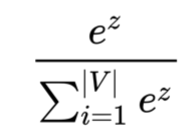

Let's see how can we achieve this using three lines of code:

    import numpy as np

    z = [2.0, 3.0, 1.0, 4.0, 2.0, 3.0, 2.0]

    np.exp(z) / np.sum(np.exp(z))
The normalized probabilities outputted by our simple code are as follows:
   array([0.06175318, 0.16786254, 0.02271772, 0.45629768, 0.06175318,
          0.16786254, 0.06175318])


#### __Inference__ :-

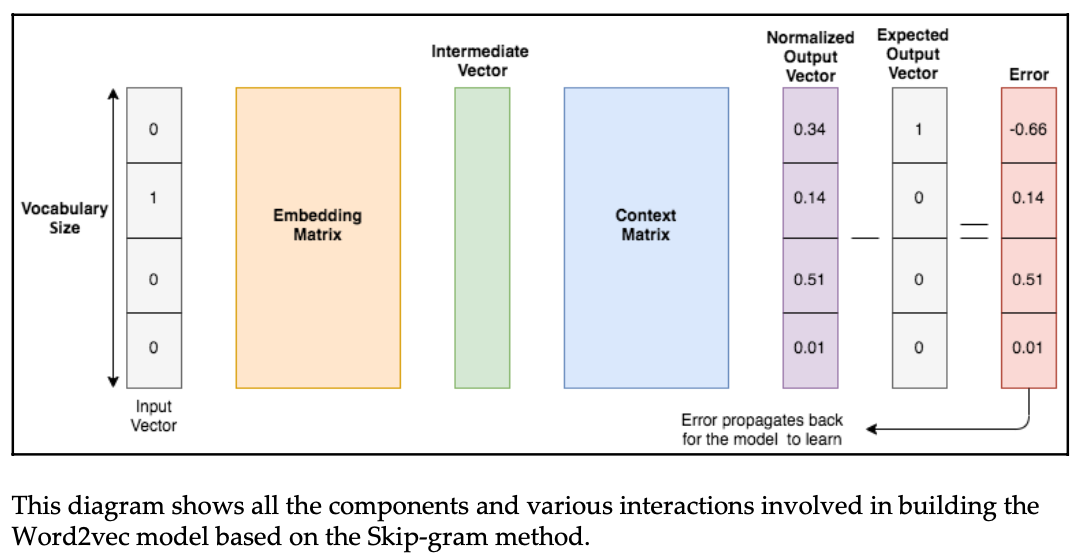



## Building Word2Vec models from scratch

In [19]:
from gensim.models import Word2Vec

sentences = [["I", "am", "trying", "to", "understand", "Natural","Language", "Processing"],
             ["Natural", "Language", "Processing", "is", "fun","to", "learn"],
             ["There", "are", "numerous", "use", "cases", "of","Natural", "Language", "Processing"]]
model = Word2Vec(sentences, min_count=1)

In [23]:
model.wv['Natural']

array([ 9.4563962e-05,  3.0773198e-03, -6.8126451e-03, -1.3754654e-03,
        7.6685809e-03,  7.3464094e-03, -3.6732971e-03,  2.6427018e-03,
       -8.3171297e-03,  6.2054861e-03, -4.6373224e-03, -3.1641065e-03,
        9.3113566e-03,  8.7338570e-04,  7.4907029e-03, -6.0740625e-03,
        5.1605068e-03,  9.9228229e-03, -8.4573915e-03, -5.1356913e-03,
       -7.0648370e-03, -4.8626517e-03, -3.7785638e-03, -8.5361991e-03,
        7.9556061e-03, -4.8439382e-03,  8.4236134e-03,  5.2625705e-03,
       -6.5500261e-03,  3.9578713e-03,  5.4701497e-03, -7.4265362e-03,
       -7.4057197e-03, -2.4752307e-03, -8.6257253e-03, -1.5815723e-03,
       -4.0343284e-04,  3.2996845e-03,  1.4418805e-03, -8.8142155e-04,
       -5.5940580e-03,  1.7303658e-03, -8.9737179e-04,  6.7936908e-03,
        3.9735902e-03,  4.5294715e-03,  1.4343059e-03, -2.6998555e-03,
       -4.3668128e-03, -1.0320747e-03,  1.4370275e-03, -2.6460087e-03,
       -7.0737829e-03, -7.8053069e-03, -9.1217868e-03, -5.9351693e-03,
      

Size of each word vector

In [24]:
model.vector_size

100

In [30]:
len(model.wv)

17

Building a 2nd Word2Vec model restricting the vocabulary using min_count

In [31]:
model = Word2Vec(sentences, min_count=2)

In [32]:
model.wv["Natural"]

array([ 9.4563962e-05,  3.0773198e-03, -6.8126451e-03, -1.3754654e-03,
        7.6685809e-03,  7.3464094e-03, -3.6732971e-03,  2.6427018e-03,
       -8.3171297e-03,  6.2054861e-03, -4.6373224e-03, -3.1641065e-03,
        9.3113566e-03,  8.7338570e-04,  7.4907029e-03, -6.0740625e-03,
        5.1605068e-03,  9.9228229e-03, -8.4573915e-03, -5.1356913e-03,
       -7.0648370e-03, -4.8626517e-03, -3.7785638e-03, -8.5361991e-03,
        7.9556061e-03, -4.8439382e-03,  8.4236134e-03,  5.2625705e-03,
       -6.5500261e-03,  3.9578713e-03,  5.4701497e-03, -7.4265362e-03,
       -7.4057197e-03, -2.4752307e-03, -8.6257253e-03, -1.5815723e-03,
       -4.0343284e-04,  3.2996845e-03,  1.4418805e-03, -8.8142155e-04,
       -5.5940580e-03,  1.7303658e-03, -8.9737179e-04,  6.7936908e-03,
        3.9735902e-03,  4.5294715e-03,  1.4343059e-03, -2.6998555e-03,
       -4.3668128e-03, -1.0320747e-03,  1.4370275e-03, -2.6460087e-03,
       -7.0737829e-03, -7.8053069e-03, -9.1217868e-03, -5.9351693e-03,
      

In [33]:
len(model.wv)

4

To Get Word Frequency (Count)

In [36]:
model.wv.get_vecattr('Natural', 'count')

np.int64(3)

In [37]:
model.vector_size

100

Building a 2nd Word2Vec model restricting the vocabulary using min_count and each vector of size 300

In [49]:
model = Word2Vec(sentences, min_count=2, vector_size = 300)

In [50]:
model.vector_size

300

Vocabulary

In [53]:
model.wv.key_to_index

{'Processing': 0, 'Language': 1, 'Natural': 2, 'to': 3}

In [54]:
model.wv["Natural"]

array([ 2.71075731e-03, -1.48577814e-03, -3.56119068e-04,  3.35454941e-04,
       -6.37046469e-05,  3.82725790e-04,  2.03795359e-03, -6.75718002e-06,
       -1.08198845e-03, -5.03576186e-04,  1.96576631e-03,  5.04700758e-04,
       -2.41420668e-04,  3.11108236e-03, -1.64042786e-03, -2.79469881e-04,
        3.05847055e-03,  2.24980921e-03,  5.00952010e-04, -2.96085351e-03,
        3.82915343e-04, -7.62751908e-04,  3.12274578e-03,  4.03309270e-04,
        4.96687891e-04,  8.02136667e-04, -6.12002215e-04, -1.66654470e-03,
        7.74764994e-05, -6.71393471e-04,  2.20031105e-03,  2.98004108e-03,
       -2.24918127e-04,  9.92338290e-04, -2.03588489e-03,  5.66441624e-04,
       -2.30874424e-03, -2.89800880e-03, -1.96673442e-03, -2.98549165e-03,
        2.42586504e-03, -1.92401046e-03,  2.75878399e-03, -2.41451501e-03,
        1.14055828e-03,  3.22499941e-03, -2.59514921e-03, -3.31501919e-03,
       -1.44304871e-03, -8.94376833e-04, -9.04297849e-05, -2.94385036e-03,
       -2.87251920e-03,  

In [43]:
len(model.wv)

4

Building a 4th Word2Vec model using 2 worker threads, skipgram approach and negative sampling\
Some other important parameters are as follows:
* `sg`, whose value when 1 uses the Skip-gram approach and, when 0, uses the CBOW approach
* `negative`, which when greater than 0, indicates that negative sampling should be used and the integer value signifies the number of negative samples to use 
* `workers`, which defines the number of threads to use for training

In [45]:
model = Word2Vec(sentences, min_count=1, vector_size = 300, workers = 2, sg = 1, negative = 1)

In [46]:
len(model.wv)

17

Vocabulary

In [48]:
model.wv.key_to_index

{'Processing': 0,
 'Language': 1,
 'Natural': 2,
 'to': 3,
 'of': 4,
 'cases': 5,
 'use': 6,
 'numerous': 7,
 'are': 8,
 'There': 9,
 'learn': 10,
 'fun': 11,
 'is': 12,
 'understand': 13,
 'trying': 14,
 'am': 15,
 'I': 16}

In [55]:
model.vector_size

300

##### Limitations of Word2vec

The Word2vec model has some limitations. Let's take the following two sentences:\
   `I am eating an apple.`\
   `I am using an apple desktop.`
   
`apple` in the first sentence signifies the <u>fruit</u> and, in the second sentence, it signifies the <u>company</u>. However, the word vector generated for apple would be the same for both the company and the fruit. In other words, since a static embedding is created for each word after the training, generating an embedding on the fly based on the context for a word's specific usage is a limitation of the Word2vec model.

## Word mover’s distance

They define the dissimilarity between two text documents as the minimum amount of distance that the embedded words of one document need to travel to reach the embedded words of another document.

Let's look at an example that the authors use in their research paper:

   _Sentence 1:_ `Obama speaks to the media in Illinois.`\
   _Sentence 2:_ `President greets the press in Chicago.`

Based on the Word2vec model, the embedding for Obama would be very close to President. Similarly, speaks would be pretty close to greets, media would be pretty close to press, and Illinois would map pretty closely to Chicago.

Let's take a look at a third sentence—`Apple is my favorite company.` Now, this is likely to be more distant to sentence 1 than sentence 2 is. This is because there is not much of a semantic relationship between the words in the first and third sentences.

WMD computes the __pairwise Euclidean distance__ between words across the sentences and it defines the distance between two documents as the minimum cumulative cost in terms of the Euclidean distance required to move all the words from the first sentence to the second sentence.


##### Word Mover's Distance as a Dissimilarity/Similarity Measure

In [56]:
import gensim
from gensim.models import KeyedVectors

In [57]:
model=KeyedVectors.load_word2vec_format('/Users/shekhabdullahayubi/Documents/Word2vec-model/GoogleNews-vectors-negative300.bin',binary=True)

In [58]:
sentence_1 = "Obama speaks to the media in Illinois"
sentence_2 = "President greets the press in Chicago"
sentence_3 = "Apple is my favorite company"

Compute the Word Mover's Distance between the sentences

In [62]:
word_mover_distance = model.wmdistance(sentence_1, sentence_2)
word_mover_distance

0.42775672224652717

In [63]:
word_mover_distance = model.wmdistance(sentence_1, sentence_3)
word_mover_distance

0.47793246759368413

Normalizing the word embeddings to get a best measure of distance

In [66]:
model.fill_norms(force=True)

Note :- Below are few revised improvement in recent release of Gensim 4.0+ (and for 2026) -

1. __Automatic Normalization:__ You rarely need to call this manually anymore. Methods like most_similar() will call fill_norms() internally the first time they are used.
2. __No "Replacement" Needed:__ In older versions, replace=True deleted the raw (unnormalized) vectors to save RAM, making the model "read-only." In modern Gensim, fill_norms() simply ensures the unit-normalized versions are cached and ready for use.
3. __Memory Management:__ If you are strictly trying to save memory, the 2026 best practice is to save your vectors and reload them using memory mapping